In [12]:
import numpy as np
import matplotlib.pyplot as plt

https://gemini.google.com/app/1377fd2cd29d1a34
- 在于 $\theta_j$ 是一个等比数列（通常基数为 $10000^{-2j/d}$），指数级衰减，涵盖了从高频到低频的频谱。
    - $\theta_j = \frac{1}{10000^{2j/d}}$
    - $\log(\theta_j) = -\frac{2j}{d} \cdot \log(10000)$
- 一个embedding（q, k）内同时考虑了短距离和长距离依赖，RoPE **多尺度（Multi-scale）**的特性
    - $\text{Score} \propto \cos((m - n) \cdot \theta_j)$
        - Attention $\text{Score}$ （softmax 之前）决定了模型在处理第 $m$ 个词（Query）时，应该给予第 $n$ 个词（Key）多少关注度。
    - 频率越高（dim index 越小,subspace），短距离依赖；捕捉语法依赖、词组搭配（如 "New" 后面接 "York"）。
        - $\cos$ 函数随距离 $m-n$ 的变化剧烈震荡。
    - 频率越低（dim index 越大），对相对位置越不敏感，长距离依赖；捕捉语义依赖、段落结构、长距离指代（如文章开头的 "Harry" 和结尾的 "he"）。
        - $\theta_j$ 极小（如 $10000^{-1}$），导致 $(m-n)\theta_j$ 增长非常慢。
- 导致了一种**Long-term Decay（远程衰减）的自然涌现：由于 RoPE 在不同维度上有不同的频率 $\theta_i$，对于远距离的 $m-n$，高频维度旋转得非常剧烈（相位随机化），低频维度旋转缓慢。当我们在所有维度（Head Dimension）上求和计算最终 Attention Score 时，远距离带来的剧烈相位震荡会相互抵消，导致内积期望值趋向于 0。这就是 RoPE 如何在数学上实现“主要关注局部，但也保留远程能力”**的机制。
    - 一方面是距离（token 之间的距离)，一方面是 embedding 内部的 dim index
    - RoPE 的长距离衰减其实是 “高频维度的完全抵消”（左侧的 subspace） + “低频维度的缓慢下降”（右侧的 subspace） 共同作用的结果。

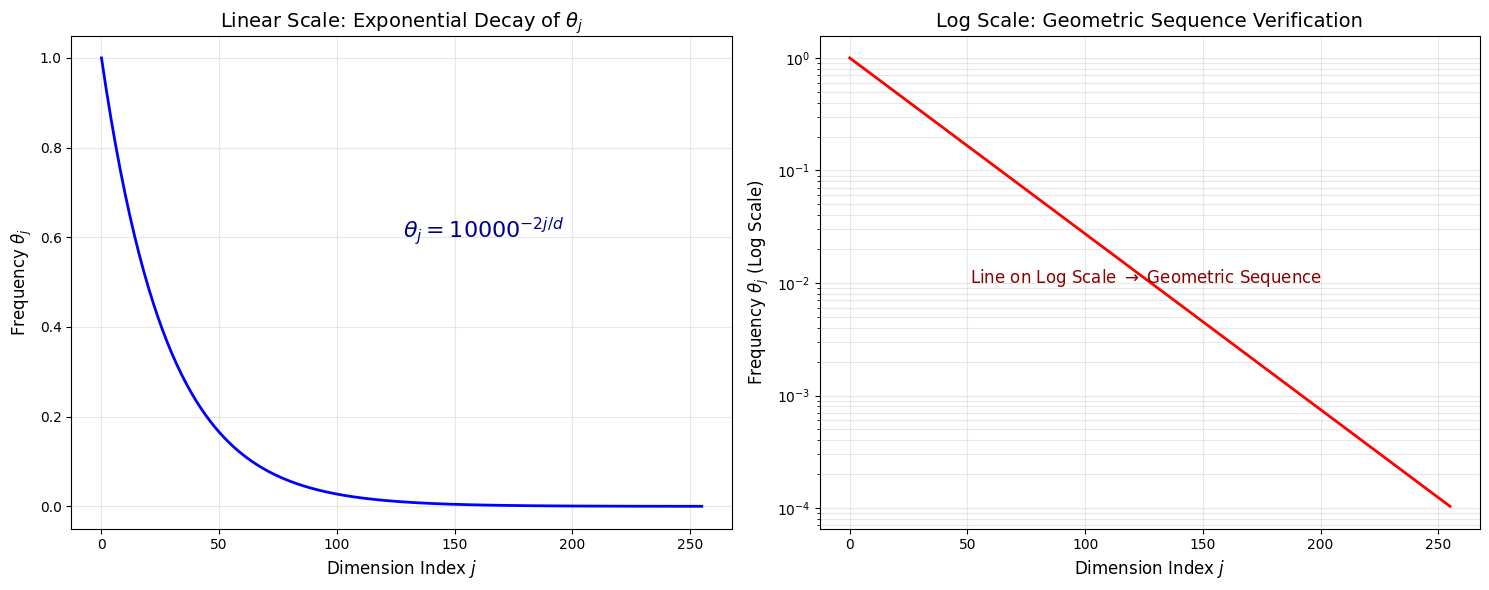

In [14]:
# Parameters
d_model = 512
j = np.arange(0, d_model // 2)

# Formula: theta_j = 10000^(-2j/d)
theta = 10000 ** (-2 * j / d_model)

# Create the visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Linear Scale
ax1.plot(j, theta, linewidth=2, color='blue')
ax1.set_title(r'Linear Scale: Exponential Decay of $\theta_j$', fontsize=14)
ax1.set_xlabel(r'Dimension Index $j$', fontsize=12)
ax1.set_ylabel(r'Frequency $\theta_j$', fontsize=12)
ax1.grid(True, alpha=0.3)
ax1.text(d_model//4, 0.6, r'$\theta_j = 10000^{-2j/d}$', fontsize=16, color='darkblue')

# Plot 2: Log Scale (y-axis)
ax2.plot(j, theta, linewidth=2, color='red')
ax2.set_yscale('log')
ax2.set_title(r'Log Scale: Geometric Sequence Verification', fontsize=14)
ax2.set_xlabel(r'Dimension Index $j$', fontsize=12)
ax2.set_ylabel(r'Frequency $\theta_j$ (Log Scale)', fontsize=12)
ax2.grid(True, which="both", ls="-", alpha=0.3)
ax2.text(d_model//10, 0.01, r'Line on Log Scale $\rightarrow$ Geometric Sequence', fontsize=12, color='darkred')

plt.tight_layout()

### $q^Tk$

> 通过绝对位置编码（赋予旋转矩阵以位置有关的绝对(absolute)旋转角度）来实现相对位置（relative）编码（rot q_m * rot k_n 向量乘机获得相对角度）

$$
\text{Score} = (\mathcal{R}_m \mathbf{q})^T (\mathcal{R}_n \mathbf{k})= \mathbf{q}^T \mathcal{R}_{n-m} \mathbf{k}
$$
- 定义相对距离角度 $\lambda = (m-n)\theta$。注意：$\mathcal{R}_{n-m}$ 相当于旋转了 $-(m-n)\theta$，即 $-\lambda$。
- $\mathcal{R}_{n-m} = \begin{pmatrix} \cos(-\lambda) & -\sin(-\lambda) \\ \sin(-\lambda) & \cos(-\lambda) \end{pmatrix} = \begin{pmatrix} \cos \lambda & \sin \lambda \\ -\sin \lambda & \cos \lambda \end{pmatrix}$

$$
\text{Score} = \mathbf{q}^T \begin{pmatrix} \cos \lambda & \sin \lambda \\ -\sin \lambda & \cos \lambda \end{pmatrix} \mathbf{k}
$$

- 展开后：$q_0 k_0 \cos \lambda + q_0 k_1 \sin \lambda + q_1 k_1 \cos \lambda - q_1 k_0 \sin \lambda$

$$
\text{Score} = \underbrace{(\mathbf{q}^T \mathbf{k}) \cdot \cos((m-n)\theta)}_{\text{语义相似度} \times \text{位置衰减}} + \underbrace{(q_0 k_1 - q_1 k_0) \cdot \sin((m-n)\theta)}_{\text{正交分量} \times \text{位置顺序}}
$$

- 更一般的 ($\tau=(m-n)$)

$$
\text{Score}_j = \underbrace{(q_{2j}k_{2j} + q_{2j+1}k_{2j+1})}_{\text{内容相似度 (实部)}} \cos(\tau\theta_j) + \underbrace{(q_{2j}k_{2j+1} - q_{2j+1}k_{2j})}_{\text{交叉项 (虚部)}} \sin(\tau\theta_j)
$$

$$q_m^T k_n = \underbrace{\|q_m\| \|k_n\|}_{\text{语义相似度}} \cdot \underbrace{\cos((m - n) \cdot \theta_j)}_{\text{位置调节系数}}$$

### $S(\tau)$: attention score 关于 $\tau=(m-n)$ 的函数

$$
S(\tau) \approx \sum_{j=0}^{d/2-1} \cos(\tau \cdot \theta_j)
$$
- $\text{Score}_j = \underbrace{(q_{2j}k_{2j} + q_{2j+1}k_{2j+1})}_{\text{内容相似度 (实部)}} \cos(\tau\theta_j) + \underbrace{(q_{2j}k_{2j+1} - q_{2j+1}k_{2j})}_{\text{交叉项 (虚部)}} \sin(\tau\theta_j)$
- 当我们想研究 Attention 机制在最理想情况下（即 Query 和 Key 的内容完全吻合）是如何随距离衰减时，我们可以假设 $q \approx k$（或者 $q$ 和 $k$ 只是模长不同，但在该二维平面上夹角为 0）。
    - 如果 $q_j \approx k_j$，那么：
        - Sine 系数（交叉项）消失：$(q_{2j}q_{2j+1} - q_{2j+1}q_{2j}) = 0$
    - Cosine 系数（内容项）最大化：$(q_{2j}^2 + q_{2j+1}^2) = ||q_j||^2 = \text{Constant (Energy)}$
- 在这种“语义强相关”的情况下，总 Attention Score 就变成了：
    - $q^T k = \sum_{j=0}^{d/2-1} \text{Score}_j \approx \sum_{j=0}^{d/2-1} ||q_j||^2 \cos(\tau \theta_j)$
- 如果我们进一步假设所有维度的能量（模长）是均匀分布的（归一化为 1），公式就简化为你所写的：
$$S(\tau) \approx \sum_{j=0}^{d/2-1} \cos(\tau \cdot \theta_j)$$

### viz

$$
\theta_j = \frac{1}{\text{base}^{2j/d}}
$$

- base: 通常默认为 $10000$（这也是原始 Transformer/RoPE 论文和 LLaMA 1/2 的标准设置）。
- $j$ (索引): 对于最低频维度（最后一个维度），$j$ 取最大值，即 $d/2 - 1$。
- 近似: 当模型维度 $d$ 比较大（比如 512, 4096 等）时，指数 $\frac{2j}{d} = \frac{2(d/2 - 1)}{d} = \frac{d-2}{d} \approx 1$。
- 最低频维度的频率近似为：$\theta_{\text{min}} \approx \frac{1}{\text{base}^1} = \frac{1}{10000}$
$$\text{旋转角度} = \text{距离} \times \text{频率}=m\theta_j$$
- $\frac{\pi}{2} = \text{Distance} \times \frac{1}{10000}$
    - $\text{Distance} \approx \mathbf{15,707}$
- $\pi = \text{Distance} \times \frac{1}{10000}$
    - $\text{Distance} \approx \mathbf{31,415}$
- $T \approx 2\pi \times \text{Base} \approx 6.28 \times 10000 = 62,800$
    - 在第 0 个 Token 和第 62832 个 Token 处，这个“转得最慢的指针”（低频维度）刚好转完了一整圈（$360^\circ$），回到了原点。
- 正负抵消（波的**干涉（Interference）**）
    - 余弦函数 $\cos(x)$ 的值域是 $[-1, 1]$。它的平均值是 0。对于高频维度集合 $\{j_{high}\}$，当 $\delta$ 很大时，相位 $\delta \cdot \theta_j$ 看起来就像是在 $[0, 2\pi]$ 区间上均匀随机采样的一组数。正数和负数大概率会互相抵消。根据大数定律，只要采样的点够多且分布均匀，它们的平均值就会无限趋近于 $\cos$ 的数学期望，也就是 0。
- 想象你要计算 $\sum \cos(\dots)$：
    - 情况 A（近距离，相干叠加）：$1 + 0.99 + 0.98 + 0.95 \approx \mathbf{4}$(大家都是正数，累加值很大)
    - 情况 B（远距离，非相干/相消叠加）：$0.5 + (-0.6) + (-0.8) + 0.9 \approx \mathbf{0}$(有正有负，加完白忙活)
- $S(\tau)$: attention score 关于 $\tau=(m-n)$ 的函数
    - 是一个距离衰减函数，或者叫 position prior（不涉及 learning)

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

<>:38: SyntaxWarning: invalid escape sequence '\d'
<>:38: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_1929273/2435012419.py:38: SyntaxWarning: invalid escape sequence '\d'
  plt.plot(x_ref, y_ref, 'k--', label='Ref: $O(\delta^{-1})$', alpha=0.5)


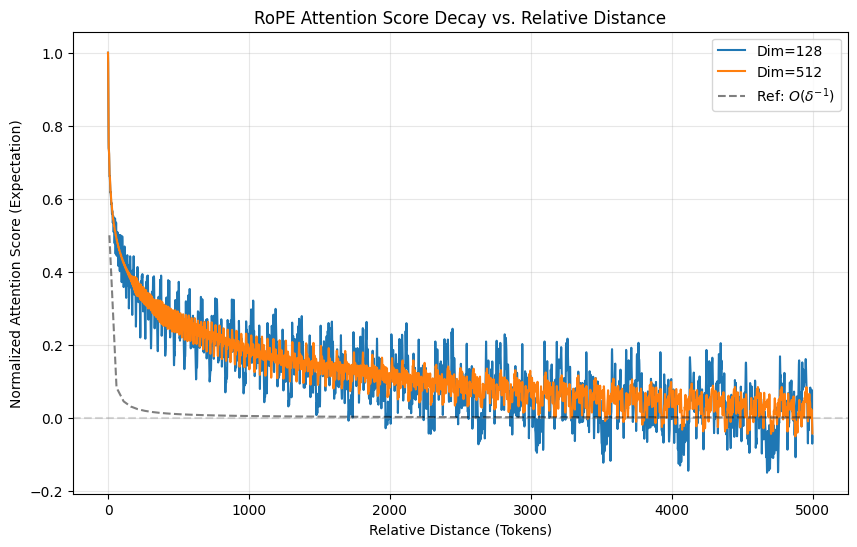

In [11]:
def quantify_rope_decay(d_model=128, max_distance=1000, base=10000):
    """
    量化 RoPE 的距离衰减特性
    """
    dim = d_model // 2
    # 生成 theta
    theta = 1.0 / (base ** (2 * np.arange(dim) / d_model))
    
    decay_scores = []
    distances = np.arange(max_distance)
    
    # 我们只关心旋转带来的衰减，所以假设 q 和 k 初始是完全对齐的单位向量
    # 这样 score(0) 应该是 1 (最大值)
    # Score(delta) = sum(cos(delta * theta)) / dim
    
    for delta in distances:
        # 计算所有维度的余弦值
        cos_values = np.cos(delta * theta)
        
        # RoPE 的核心衰减来源于这些余弦值的平均
        # 如果大家方向一致，均值为1；如果方向乱了，均值趋向于0
        avg_score = np.mean(cos_values) 
        decay_scores.append(avg_score)
        
    return distances, decay_scores

# 运行模拟
d_models = [128, 512]
plt.figure(figsize=(10, 6))

for d in d_models:
    x, y = quantify_rope_decay(d_model=d, max_distance=5000)
    plt.plot(x, y, label=f'Dim={d}')

# 添加一条 1/x 的参考线来看看是否符合幂律衰减
x_ref = np.linspace(10, 5000, 100)
y_ref = 5 / x_ref # 简单的缩放以便对比
plt.plot(x_ref, y_ref, 'k--', label='Ref: $O(\delta^{-1})$', alpha=0.5)

plt.axhline(0, color='gray', linestyle='--', alpha=0.3)
plt.title("RoPE Attention Score Decay vs. Relative Distance")
plt.xlabel("Relative Distance (Tokens)")
plt.ylabel("Normalized Attention Score (Expectation)")
plt.legend()
plt.grid(True, alpha=0.3)